In [1]:
from pathlib import Path

import numpy as np
from matplotlib import pyplot as plt
from vascx.fundus.loader import RetinaLoader
from vascx.fundus.features.base import LayerFeature
from vascx.fundus.features.base import VesselsLayerFeature
from vascx.fundus.features.base import RetinaFeature
from vascx.fundus.features.bifurcation_angles import BifurcationAngles
from vascx.fundus.features.bifurcation_counts import BifurcationCount
from vascx.fundus.features.caliber import Caliber
from vascx.fundus.features.temporal_angles import TemporalAngle
from vascx.fundus.features.cre import CRE, CREMode
from vascx.fundus.features.tortuosity import Tortuosity
from vascx.fundus.features.sparsity import Sparsity, SparsityMode
from vascx.fundus.features.variance_of_laplacian import VarianceOfLaplacian
from vascx.fundus.features.vascular_densities import VascularDensity
from rtnls_enface.grids.ellipse import EllipseField
from rtnls_enface.grids.etdrs import ETDRSRing as ETDRSRing
from rtnls_enface.grids.circle import CircleField
from rtnls_enface.grids.hemifields import HemifieldField
from rtnls_enface.grids.disc_centered import DiscCenteredRing
from rtnls_enface.grids import ETDRSQuadrant
from rtnls_enface.grids.specifications import DiscCenteredGridSpecification, ETDRSGridSpecification, EllipseGridSpecification, GridFieldSpecification
from vascx.shared.aggregators import median

from rtnls_enface.utils.plotting import plot_grid


In [2]:
ds_path = Path("../../samples/fundus")
figs_path = Path('/home/jose/vessels/rtnls_vascx/paper/figures_hq')
fig_dpi=300
loader = RetinaLoader.from_folder(ds_path)

Folder av_path: 6 files
Folder disc_path: 6 files
Folder fundus_path: 6 files
Folder vessels_path: 6 files


In [3]:
def make_plot_fn(feature):
    def plot_fn(ax, row, col, i):
        i = 3*row+col
        r = loader[i]
        if isinstance(feature, LayerFeature):
            feature.plot(ax=ax, layer=r.arteries)
        elif isinstance(feature, VesselsLayerFeature):
            feature.plot(ax=ax, layer=r.vessels)
        elif isinstance(feature, RetinaFeature):
            feature.plot(ax=ax, retina=r)
        else:
            raise ValueError(f"Unknown feature type: {type(feature)}")
    return plot_fn

In [4]:
feat = Sparsity(mode=SparsityMode.MAX)
DISC_FULL = GridFieldSpecification(DiscCenteredGridSpecification(multiplier=1.2), DiscCenteredRing.FullGrid)
ELLIPSE_FULL = GridFieldSpecification(EllipseGridSpecification(), EllipseField.FullGrid)
ETDRS_FULL = GridFieldSpecification(ETDRSGridSpecification(multiplier=1.5), ETDRSRing.FullGrid)

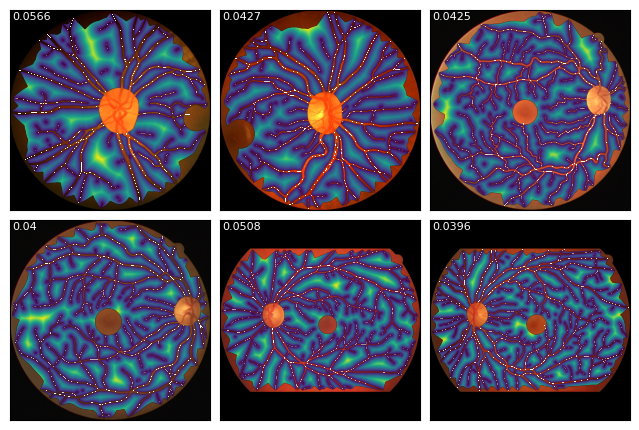

In [5]:
fig, axs = plot_grid(make_plot_fn(Sparsity(mode=SparsityMode.MEAN)), ncols=3, nrows=2)
if figs_path is not None:
    fig.savefig(figs_path / "sparsity_mean.png", dpi=fig_dpi, bbox_inches="tight")

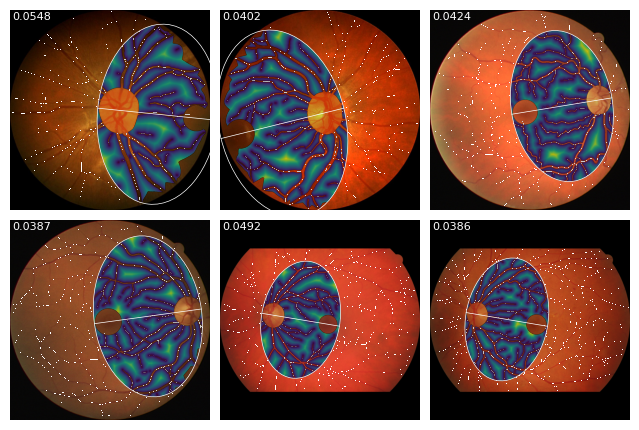

In [5]:
fig, axs = plot_grid(make_plot_fn(Sparsity(mode=SparsityMode.MEAN, grid_field=ELLIPSE_FULL)), ncols=3, nrows=2)
if figs_path is not None:
    fig.savefig(figs_path / "sparsity_mean.png", dpi=fig_dpi, bbox_inches="tight")

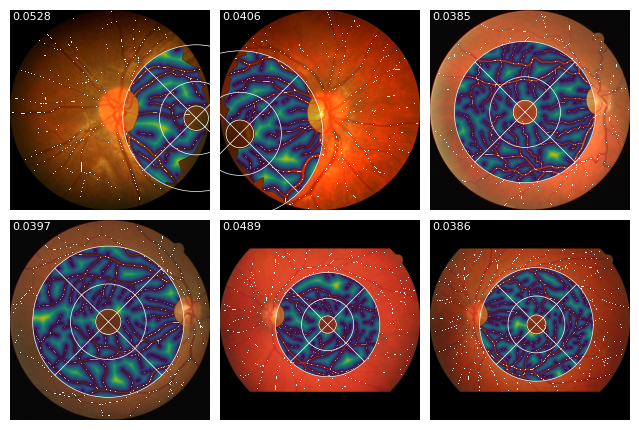

In [7]:
fig, axs = plot_grid(make_plot_fn(Sparsity(mode=SparsityMode.MEAN, grid_field=ETDRS_FULL)), ncols=3, nrows=2)
if figs_path is not None:
    fig.savefig(figs_path / "sparsity_mean.png", dpi=fig_dpi, bbox_inches="tight")

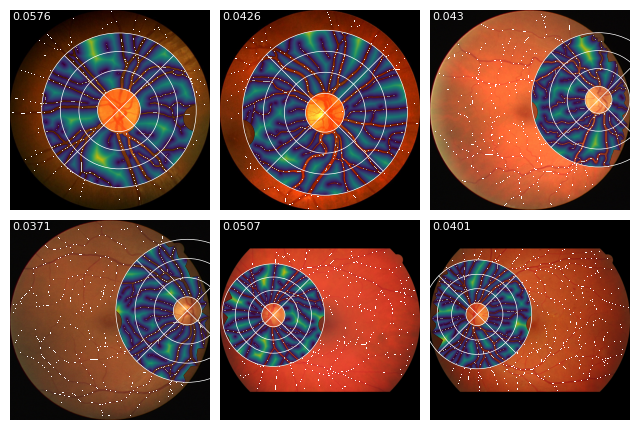

In [8]:
fig, axs = plot_grid(make_plot_fn(Sparsity(mode=SparsityMode.MEAN, grid_field=DISC_FULL)), ncols=3, nrows=2)
if figs_path is not None:
    fig.savefig(figs_path / "sparsity_mean.png", dpi=fig_dpi, bbox_inches="tight")

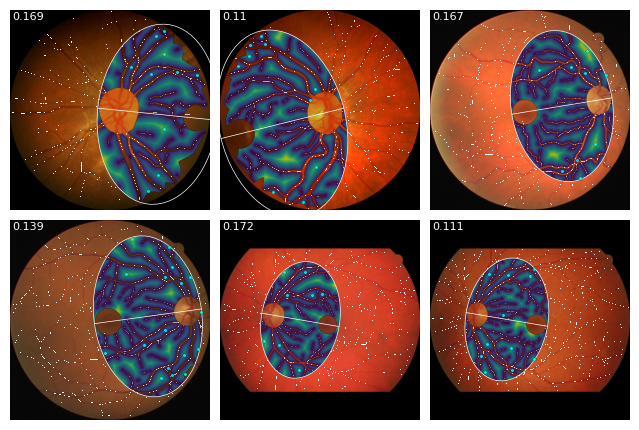

In [9]:
fig, axs = plot_grid(make_plot_fn(Sparsity(mode=SparsityMode.MAX, grid_field=ELLIPSE_FULL)), ncols=3, nrows=2)
if figs_path is not None:
    fig.savefig(figs_path / "sparsity.png", dpi=fig_dpi, bbox_inches="tight")